## Sportmonks Germany 201 — 03: Attacking aggressiveness

**Hypothesis (proxy):** aggressive attacking shows up as **shot volume**, **territory** proxies (corners, dangerous attacks if present), and **xG** when your Sportmonks plan exposes `xGFixture`.

**Derived:** shots per “possession not held” proxy: `shots / max(100 - opp_possession_pct, 1)`.

Prerequisite: notebook 01 outputs (`fixtures_germany_201.csv`, `germany_201_meta.json`).

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

ROOT = Path.cwd()
if (ROOT / "sportmonks").is_dir():
    SPORTMONKS_DIR = ROOT / "sportmonks"
    sys.path.insert(0, str(SPORTMONKS_DIR))
else:
    SPORTMONKS_DIR = ROOT
    sys.path.insert(0, str(ROOT))

import sportmonks_germany_api as smg

In [2]:
load_dotenv(".env")

API_TOKEN = os.getenv("API_TOKEN")

In [3]:
meta_path = SPORTMONKS_DIR / "germany_201_meta.json"
GERMANY_TEAM_ID = int(json.loads(meta_path.read_text(encoding="utf-8"))["germany_team_id"])
fixtures = pd.read_csv(SPORTMONKS_DIR / "fixtures_germany_201.csv", parse_dates=["starting_at"])

### Per-fixture fetch: `statistics.type`, optional `xGFixture` / `participants`

Single request per match. **`xGFixture`** and full **`participants`** may require a higher Sportmonks plan (API **403** if not included—same idea as omitting `pressure` in notebook 02). The code tries richer `include` strings first, then falls back to `statistics.type` only so core match stats still load. `xg_for_germany` stays empty unless your plan returns `xGFixture` (and participants when needed for home/away mapping).

In [4]:
MAX_FIXTURES = None
# Omit includes not on your plan (403 otherwise). Richest first; API falls back on 403.
INCLUDE_CANDIDATES = [
    "statistics.type;xGFixture;participants",
    "statistics.type;xGFixture",
    "statistics.type;participants",
    "statistics.type",
]


def pick(sd: dict, *keys: str) -> float:
    for k in keys:
        if k in sd and sd[k] == sd[k]:
            return float(sd[k])
    return float("nan")


rows = []
ids = fixtures["id"].tolist()
if MAX_FIXTURES is not None:
    ids = ids[: int(MAX_FIXTURES)]

for fid in ids:
    data, _used_include = smg.get_fixture_with_include_fallback(
        API_TOKEN, int(fid), INCLUDE_CANDIDATES
    )
    stats_df = smg.normalize_fixture_statistics(data)
    g = smg.stats_dict_for_team(stats_df, GERMANY_TEAM_ID)
    oid = smg.opponent_participant_id(stats_df, GERMANY_TEAM_ID)
    o = smg.stats_dict_for_team(stats_df, oid) if oid is not None else {}

    shots = pick(g, "shots-total", "shots_total", "shots", "SHOTS_TOTAL")
    sot = pick(g, "shots-on-target", "shots_on_target", "SHOTS_ON_TARGET")
    corners = pick(g, "corners", "CORNERS", "corner-kicks")
    attacks = pick(g, "attacks", "ATTACKS")
    dangerous = pick(
        g, "dangerous-attacks", "dangerous_attacks", "DANGEROUS_ATTACKS"
    )
    big_chances = pick(
        g, "big-chances", "big_chances", "BIG_CHANCES", "big-chances-created"
    )
    poss = pick(g, "ball-possession", "ball_possession", "BALL_POSSESSION")
    opp_poss = pick(o, "ball-possession", "ball_possession", "BALL_POSSESSION")
    if not (opp_poss == opp_poss) and poss == poss:
        opp_poss = 100.0 - poss
    shots_per_low_poss = shots / max(100.0 - opp_poss, 1.0)

    xg_home = xg_away = float("nan")
    xgf = data.get("xGFixture")
    if isinstance(xgf, list) and xgf:
        xdf = pd.json_normalize(xgf)
        if not xdf.empty:
            for hc, ac in [
                ("home_xg", "away_xg"),
                ("xg.home", "xg.away"),
            ]:
                if hc in xdf.columns and ac in xdf.columns:
                    xg_home = float(xdf.iloc[0][hc])
                    xg_away = float(xdf.iloc[0][ac])
                    break

    ger_xg = float("nan")
    parts = data.get("participants") or []
    if parts and xg_home == xg_home:
        meta = pd.json_normalize(parts)
        if "meta.location" in meta.columns and "id" in meta.columns:
            loc = meta.set_index("id")["meta.location"]
            if GERMANY_TEAM_ID in loc.index:
                side = str(loc[GERMANY_TEAM_ID]).lower()
                ger_xg = xg_home if side == "home" else xg_away

    row_fix = fixtures.loc[fixtures["id"] == fid].iloc[0]
    rows.append(
        {
            "fixture_id": int(fid),
            "starting_at": row_fix["starting_at"],
            "league_id": int(row_fix["league_id"]),
            "shots": shots,
            "shots_on_target": sot,
            "corners": corners,
            "attacks": attacks,
            "dangerous_attacks": dangerous,
            "big_chances": big_chances,
            "possession_pct": poss,
            "opp_possession_pct": opp_poss,
            "shots_per_low_opp_possession": shots_per_low_poss,
            "xg_for_germany": ger_xg,
        }
    )

atk_df = pd.DataFrame(rows)
atk_df.head()

,fixture_id,starting_at,league_id,shots,shots_on_target,corners,attacks,dangerous_attacks,big_chances,possession_pct,opp_possession_pct,shots_per_low_opp_possession,xg_for_germany
0,19032613,2024-06-14 19:00:00,1326,20.0,10.0,5.0,133.0,77.0,NaN,73.0,27.0,0.273973,NaN
1,19032614,2024-06-19 16:00:00,1326,19.0,7.0,11.0,125.0,84.0,NaN,64.0,36.0,0.296875,NaN
2,19032615,2024-06-23 19:00:00,1326,18.0,3.0,9.0,116.0,71.0,NaN,66.0,34.0,0.272727,NaN
3,19032605,2024-06-29 19:00:00,1326,15.0,9.0,6.0,116.0,51.0,NaN,54.0,46.0,0.277778,NaN
4,19032601,2024-07-05 16:00:00,1326,23.0,5.0,5.0,NaN,NaN,5.0,52.0,48.0,0.442308,NaN


In [5]:
out = SPORTMONKS_DIR / "germany_attacking_features.csv"
atk_df.to_csv(out, index=False)

In [6]:
league_labels = {1326: "Euro 2024", 1538: "Nations League 25", 720: "WCQ Europe"}
atk_df["competition"] = atk_df["league_id"].map(league_labels).fillna(
    atk_df["league_id"].astype(str)
)

atk_df.groupby("competition").agg(
    matches=("fixture_id", "count"),
    shots_median=("shots", "median"),
    sot_median=("shots_on_target", "median"),
    xg_median=("xg_for_germany", "median"),
)

,matches,shots_median,sot_median,xg_median
competition,,,,
Euro 2024,5,19.0,7.0,NaN
Nations League 25,10,16.5,5.0,NaN
WCQ Europe,6,14.0,6.5,NaN


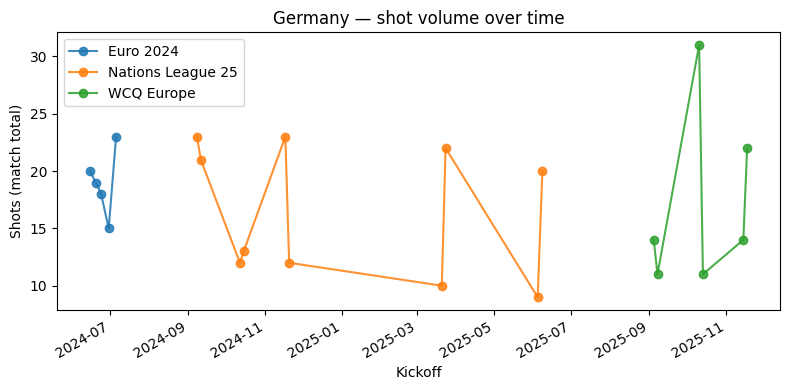

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for comp, sub in atk_df.groupby("competition"):
    sub = sub.sort_values("starting_at")
    ax.plot(sub["starting_at"], sub["shots"], marker="o", linestyle="-", label=comp, alpha=0.85)
ax.set_ylabel("Shots (match total)")
ax.set_xlabel("Kickoff")
ax.legend()
ax.set_title("Germany — shot volume over time")
fig.autofmt_xdate()
plt.tight_layout()